# data

[link](https://www.kaggle.com/datasets/johnjdavisiv/urinary-biomarkers-for-pancreatic-cancer/data)

| Column name               | Original column name         | Details |
|---------------------------|-----------------------------|---------|
| sample_id                 | Sample ID                   | Unique string identifying each subject |
| patient_cohort            | Patient's Cohort            | Cohort 1: previously used samples; Cohort 2: newly added samples |
| sample_origin             | Sample Origin               | BPTB: Barts Pancreas Tissue Bank, London, UK; ESP: Spanish National Cancer Research Centre, Madrid, Spain; LIV: Liverpool University, UK; UCL: University College London, UK |
| age                       | Age                         | Age in years |
| sex                       | Sex                         | M = male, F = female |
| diagnosis                 | Diagnosis (1=Control, 2=Benign, 3=PDAC) | 1 = control (no pancreatic disease), 2 = benign hepatobiliary disease (119 of which are chronic pancreatitis), 3 = Pancreatic ductal adenocarcinoma (pancreatic cancer) |
| stage                     | Stage                       | For those with pancreatic cancer, one of IA, IB, IIA, IIIB, III, IV |
| benign_sample_diagnosis   | Benign Samples Diagnosis    | For those with a benign, non-cancerous diagnosis, what was the diagnosis? |
| plasma_CA19_9             | Plasma CA19-9 U/ml          | Blood plasma levels of CA 19–9, often elevated in pancreatic cancer. Only assessed in 350 patients. |
| creatinine                | Creatinine mg/ml            | Urinary biomarker of kidney function |
| LYVE1                     | LYVE1 ng/ml                 | Urinary levels of Lymphatic vessel endothelial hyaluronan receptor 1, may play a role in tumor metastasis |
| REG1B                     | REG1B ng/ml                 | Urinary levels of a protein that may be associated with pancreas regeneration |
| TFF1                      | TFF1 ng/ml                  | Urinary levels of Trefoil Factor 1, related to regeneration and repair of urinary tract |
| REG1A                     | REG1A ng/ml                 | Urinary levels of a protein associated with pancreas regeneration. Only assessed in 306 patients. |


In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# 통계 검정
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
# ml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
# 모델 후보
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Data

In [12]:
df = pd.read_csv('../../../delete/Debernardi et al 2020 data.csv')

In [13]:
df

,sample_id,patient_cohort,sample_origin,age,sex,diagnosis,stage,benign_sample_diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A
0,S1,Cohort1,BPTB,33,F,1,NaN,NaN,11.7,1.83222,0.893219,52.948840,654.282174,1262.000
1,S10,Cohort1,BPTB,81,F,1,NaN,NaN,NaN,0.97266,2.037585,94.467030,209.488250,228.407
2,S100,Cohort2,BPTB,51,M,1,NaN,NaN,7.0,0.78039,0.145589,102.366000,461.141000,NaN
3,S101,Cohort2,BPTB,61,M,1,NaN,NaN,8.0,0.70122,0.002805,60.579000,142.950000,NaN
4,S102,Cohort2,BPTB,62,M,1,NaN,NaN,9.0,0.21489,0.000860,65.540000,41.088000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,S549,Cohort2,BPTB,68,M,3,IV,NaN,NaN,0.52026,7.058209,156.241000,525.178000,NaN
586,S558,Cohort2,BPTB,71,F,3,IV,NaN,NaN,0.85956,8.341207,16.915000,245.947000,NaN
587,S560,Cohort2,BPTB,63,M,3,IV,NaN,NaN,1.36851,7.674707,289.701000,537.286000,NaN
588,S583,Cohort2,BPTB,75,F,3,IV,NaN,NaN,1.33458,8.206777,205.930000,722.523000,NaN


In [6]:
df.describe()

,age,diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A
count,590.000000,590.000000,350.000000,590.000000,590.000000,590.000000,590.000000,306.000000
mean,59.079661,2.027119,654.002944,0.855383,3.063530,111.774090,597.868722,735.281222
std,13.109520,0.804873,2430.317642,0.639028,3.438796,196.267110,1010.477245,1477.247724
min,26.000000,1.000000,0.000000,0.056550,0.000129,0.001104,0.005293,0.000000
25%,50.000000,1.000000,8.000000,0.373230,0.167179,10.757216,43.961000,80.692000
50%,60.000000,2.000000,26.500000,0.723840,1.649862,34.303353,259.873974,208.538500
75%,69.000000,3.000000,294.000000,1.139482,5.205037,122.741013,742.736000,649.000000
max,89.000000,3.000000,31000.000000,4.116840,23.890323,1403.897600,13344.300000,13200.000000


In [9]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\n📊 {col}")
    print(df[col].value_counts(dropna=False))


📊 sample_id
S1      1
S588    1
S302    1
S288    1
S497    1
       ..
S282    1
S321    1
S323    1
S363    1
S590    1
Name: sample_id, Length: 590, dtype: int64

📊 patient_cohort
Cohort1    332
Cohort2    258
Name: patient_cohort, dtype: int64

📊 sample_origin
BPTB    409
LIV     132
ESP      29
UCL      20
Name: sample_origin, dtype: int64

📊 sex
F    299
M    291
Name: sex, dtype: int64

📊 stage
NaN    391
III     76
IIB     68
IV      21
IB      12
IIA     11
II       7
IA       3
I        1
Name: stage, dtype: int64

📊 benign_sample_diagnosis
NaN                                                             382
Pancreatitis                                                     41
Pancreatitis (Chronic)                                           35
Gallstones                                                       21
Pancreatitis (Alcohol-Chronic)                                   11
Cholecystitis                                                     9
Serous cystadenoma - NOS          

- crosstab between sex

In [48]:
ct = pd.crosstab(df['sex'], df['diagnosis_label'])
print(ct)

diagnosis_label  Benign  Control  PDAC
sex                                   
F                   101      115    83
M                   107       68   116


- Within-sex Proportions 

In [49]:
print("\nWithin-sex proportions (%):")
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(2))


Within-sex proportions (%):
diagnosis_label  Benign  Control   PDAC
sex                                    
F                 33.78    38.46  27.76
M                 36.77    23.37  39.86


- 남성이 많이 췌장암 발생하는 경향

- 성별 다른지 chi-square test

In [52]:
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square test p-value = {p:.4f}")

Chi-square test p-value = 0.0001


다름

- visualization

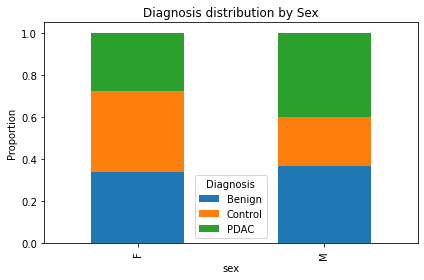

In [53]:
prop = ct.div(ct.sum(axis=1), axis=0)
prop.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title('Diagnosis distribution by Sex')
plt.ylabel('Proportion')
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

시각화해보면 딱 보임

## diagnosis level visualization by Biomarker

In [16]:
df['diagnosis_label'] = df['diagnosis'].map({1:'Control', 2:'Benign', 3:'PDAC'})

In [17]:
biomarkers = ['LYVE1', 'REG1B', 'TFF1', 'REG1A', 'plasma_CA19_9', 'creatinine']

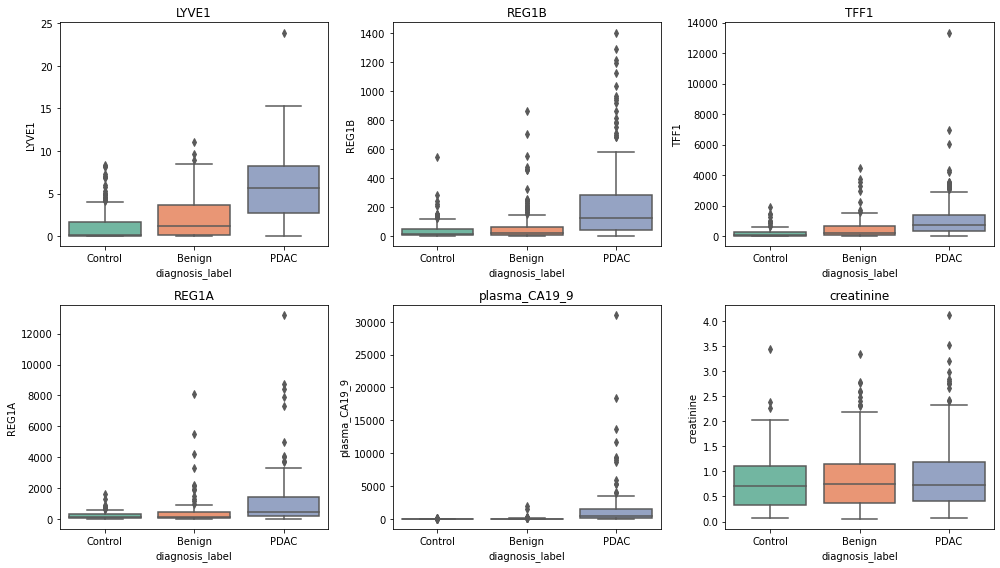

In [22]:
plt.figure(figsize=(14, 8))
for i, biomarker in enumerate(biomarkers, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='diagnosis_label', y=biomarker, palette='Set2')
    plt.title(biomarker)
    plt.tight_layout()
plt.show()

- 췌장암 환자 PDAC
    - LYVE1이 높음. REG1B가 높음 TFF1이 높음, REF1A가 높음

## Spearman Correlation

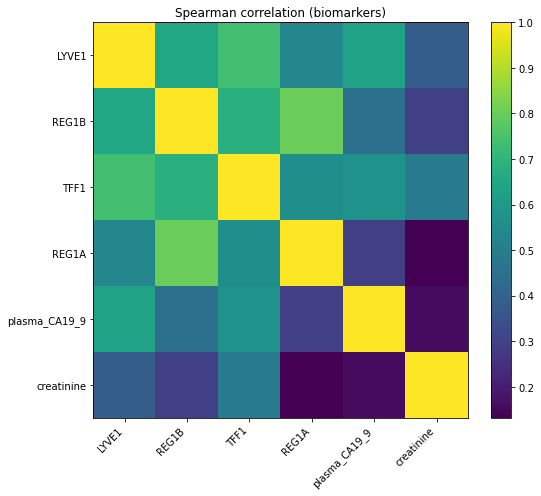

In [42]:
corr = df[biomarkers].corr(method="spearman", min_periods=20)
plt.figure(figsize=(8,7))
plt.imshow(corr, aspect="auto", interpolation="nearest")
plt.xticks(range(len(biomarkers)), biomarkers, rotation=45, ha="right")
plt.yticks(range(len(biomarkers)), biomarkers)
plt.title("Spearman correlation (biomarkers)")
plt.colorbar()
plt.tight_layout()
plt.show()

## Statistical Test

In [25]:
for biomarker in biomarkers:
    groups = [df[df['diagnosis_label'] == g][biomarker].dropna() for g in df['diagnosis_label'].unique()]
    stat, p = f_oneway(*groups)
    print(f"{biomarker}: p-value = {p:.4f}")

LYVE1: p-value = 0.0000
REG1B: p-value = 0.0000
TFF1: p-value = 0.0000
REG1A: p-value = 0.0000
plasma_CA19_9: p-value = 0.0000
creatinine: p-value = 0.1894


- dignose level 별로 그룹 간 차이가 있는지
    - creatime 빼고 다 차이 있음

## Random Forest

- target, features

In [28]:
X = df[biomarkers].fillna(0)
y = df['diagnosis']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- randomforest

In [30]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

- prediction

In [31]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.76      0.76      0.76        41
           2       0.61      0.59      0.60        39
           3       0.85      0.87      0.86        38

    accuracy                           0.74       118
   macro avg       0.74      0.74      0.74       118
weighted avg       0.74      0.74      0.74       118



### Confusion Matrix

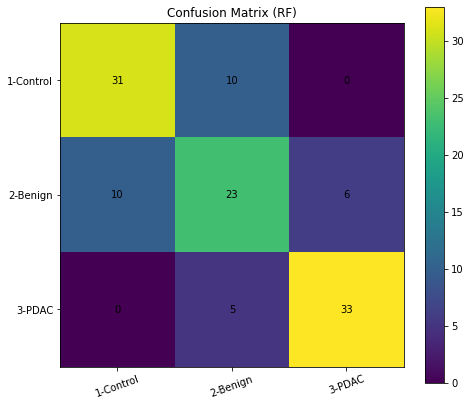

In [46]:
cm = confusion_matrix(y_test, y_pred, labels=[1,2,3])
plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (RF)")
plt.xticks([0,1,2], ["1-Control","2-Benign","3-PDAC"], rotation=20)
plt.yticks([0,1,2], ["1-Control","2-Benign","3-PDAC"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

## Check Feature Importance

In [35]:
importances = pd.Series(rf.feature_importances_, index=biomarkers).sort_values(ascending=False)
importances

plasma_CA19_9    0.241888
LYVE1            0.216604
TFF1             0.181022
REG1B            0.146198
creatinine       0.123882
REG1A            0.090405
dtype: float64

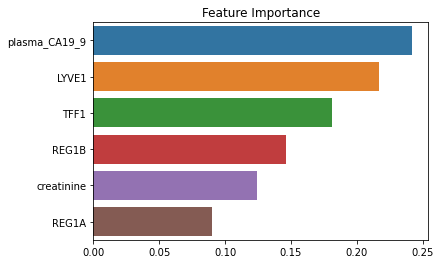

In [36]:
sns.barplot(x=importances, y=importances.index)
plt.title('Feature Importance')
plt.show()

## Logistic Regression

In [55]:
feature_cols = ["age", "creatinine", "LYVE1", "REG1B", "TFF1", "REG1A", "plasma_CA19_9"]
X = df[feature_cols].copy()
X["sex"] = df["sex"].map({"M":0, "F":1})
y = df["diagnosis"]

In [56]:
X = X.fillna(X.median())
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [57]:
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=200, multi_class='ovr'))
])
log_reg.fit(X_train, y_train)
print("\n--- Logistic Regression ---")
print(classification_report(y_test, log_reg.predict(X_test)))


--- Logistic Regression ---
              precision    recall  f1-score   support

           1       0.62      0.63      0.62        46
           2       0.60      0.52      0.56        52
           3       0.75      0.84      0.79        50

    accuracy                           0.66       148
   macro avg       0.66      0.66      0.66       148
weighted avg       0.66      0.66      0.66       148



In [58]:
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', probability=True))
])
svm.fit(X_train, y_train)
print("\n--- SVM (RBF kernel) ---")
print(classification_report(y_test, svm.predict(X_test)))


--- SVM (RBF kernel) ---
              precision    recall  f1-score   support

           1       0.61      0.72      0.66        46
           2       0.64      0.48      0.55        52
           3       0.76      0.84      0.80        50

    accuracy                           0.68       148
   macro avg       0.67      0.68      0.67       148
weighted avg       0.67      0.68      0.67       148



In [63]:
for name, model in [("LR", log_reg), ("SVM", svm)]:
    y_proba = model.predict_proba(X_test)
    auc = roc_auc_score(pd.get_dummies(y_test), y_proba, multi_class='ovr')
    print(f"log_reg macro AUC: {auc:.3f}")

log_reg macro AUC: 0.849
log_reg macro AUC: 0.843


- AUC 별 차이 없음

In [70]:
biomarkers = ["age", "creatinine", "LYVE1", "REG1B", "TFF1", "REG1A", "plasma_CA19_9"]
X = df[biomarkers].copy()
X["sex"] = df["sex"].map({"M":0, "F":1})
y = df["diagnosis"] - 1   # 0,1,2 로 바꿈 (PyTorch용)

In [71]:
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.long)

- data loader

In [72]:
class BiomarkerDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [73]:
train_dataset = BiomarkerDataset(X_train, y_train)
test_dataset = BiomarkerDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [98]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], output_dim=3, dropout=0.4):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[2], output_dim)
        )
    def forward(self, x):
        return self.layers(x)

In [99]:
input_dim = X_train.shape[1]
model = MLPClassifier(input_dim=input_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [100]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100

train_losses, test_losses = [], []

In [101]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    # Validation loss
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            val_loss += criterion(output, y_batch).item()
    test_losses.append(val_loss / len(test_loader))

    if epoch % 10 == 0:
        print(f"Epoch [{epoch}/{epochs}] Train Loss: {train_losses[-1]:.4f}  Val Loss: {test_losses[-1]:.4f}")

Epoch [0/100] Train Loss: 1.0805  Val Loss: 1.0263
Epoch [10/100] Train Loss: 0.7961  Val Loss: 0.7018
Epoch [20/100] Train Loss: 0.7519  Val Loss: 0.6944
Epoch [30/100] Train Loss: 0.6993  Val Loss: 0.6584
Epoch [40/100] Train Loss: 0.7230  Val Loss: 0.6667
Epoch [50/100] Train Loss: 0.6858  Val Loss: 0.6535
Epoch [60/100] Train Loss: 0.6685  Val Loss: 0.6601
Epoch [70/100] Train Loss: 0.6517  Val Loss: 0.6542
Epoch [80/100] Train Loss: 0.6436  Val Loss: 0.6437
Epoch [90/100] Train Loss: 0.6599  Val Loss: 0.6618


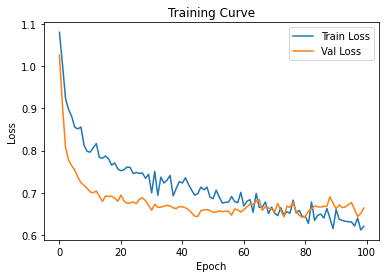

In [102]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Val Loss")
plt.legend()
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [103]:
model.eval()

MLPClassifier(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.4, inplace=False)
    (9): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [104]:
with torch.no_grad():
    preds = model(X_test.to(device)).argmax(dim=1).cpu().numpy()

In [105]:
print(classification_report(y_test, preds, target_names=["Control","Benign","PDAC"]))

              precision    recall  f1-score   support

     Control       0.61      0.89      0.73        46
      Benign       0.75      0.35      0.47        52
        PDAC       0.81      0.92      0.86        50

    accuracy                           0.71       148
   macro avg       0.72      0.72      0.69       148
weighted avg       0.73      0.71      0.68       148



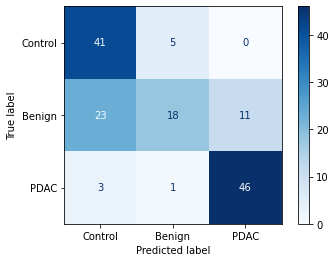

In [106]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Control","Benign","PDAC"])
disp.plot(cmap="Blues")
plt.show()